# Ablation Comparison — Memetic NAS Operator Contribution

This notebook compares the performance of the full proposed algorithm against ablation variants generated by `scripts/run_ablations.py`.

We compute per-seed Hypervolume (HV) and Inverted Generational Distance (IGD), visualise distributional differences with boxplots, compare median performance, and overlay Pareto fronts for the most illustrative crippled variants.

In [ ]:
import sys
import json
from pathlib import Path

# ── Bootstrap: find project root before any src imports ──────────────────────
_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / "src").exists() and (_parent / "requirements.txt").exists():
        PROJECT_ROOT = _parent
        break
else:
    PROJECT_ROOT = _cwd.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd, proxy_pareto,
)
from src.utils.pareto_math import compute_bounds, normalise_to_bounds

RESULTS_DIR = PROJECT_ROOT / "results" / "ablations"
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

LABEL_MAP = {
    "full_proposed":        "Full Proposed",
    "ablation_t2_no_pso":   "No PSO",
    "ablation_t3_no_ga":    "No GA",
    "ablation_t4_no_moead": "No MOEA/D",
    "ablation_t5_no_sa":    "No SA",
    "ablation_t6_no_restart": "No Restart",
}

variant_paths = {}
for path in sorted(RESULTS_DIR.glob("*.json")):
    prefix = path.stem.split("_seed")[0]
    variant_paths.setdefault(prefix, []).append(path)

if not variant_paths:
    raise FileNotFoundError(f"No ablation JSON files found in {RESULTS_DIR}.")

variants = [v for v in LABEL_MAP.keys() if v in variant_paths]
if not variants:
    variants = sorted(variant_paths.keys())

all_archives = []
for variant in variants:
    for path in variant_paths[variant]:
        payload = json.loads(path.read_text())
        all_archives.append(payload["archive"])

proxy_ref  = proxy_pareto(all_archives)
all_points = np.vstack([
    get_pareto_front(archive_to_points(archive))
    for archive in all_archives
])

_pts_min, _pts_range = compute_bounds(all_points)
normalise = lambda pts: normalise_to_bounds(pts, _pts_min, _pts_range)

REF_POINT = np.array([1.1, 1.1])

variant_metrics = []
for variant in variants:
    for path in variant_paths[variant]:
        payload = json.loads(path.read_text())
        archive = payload["archive"]
        front      = get_pareto_front(archive_to_points(archive))
        norm_front = normalise(front)
        hv  = calc_hv(norm_front, ref_point=REF_POINT)
        igd = calc_igd(norm_front, normalise(proxy_ref))
        variant_metrics.append({
            "Variant": LABEL_MAP.get(variant, variant),
            "Seed": int(path.stem.split("_seed")[-1]),
            "HV":  hv,
            "IGD": igd,
        })

metrics_df = pd.DataFrame(variant_metrics)
metrics_df["Variant"] = pd.Categorical(
    metrics_df["Variant"],
    categories=[LABEL_MAP.get(v, v) for v in variants],
    ordered=True,
)
metrics_df.head()



Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False



,Variant,Seed,HV,IGD
0,Full Proposed,0,1.058107,0.012756
1,Full Proposed,1,1.059832,0.022068
2,Full Proposed,10,1.060235,0.005508
3,Full Proposed,11,1.060823,0.004560
4,Full Proposed,12,1.062078,0.029285


/tmp/ipykernel_10246/2376242125.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablations/ablation_hv_boxplot.pdf


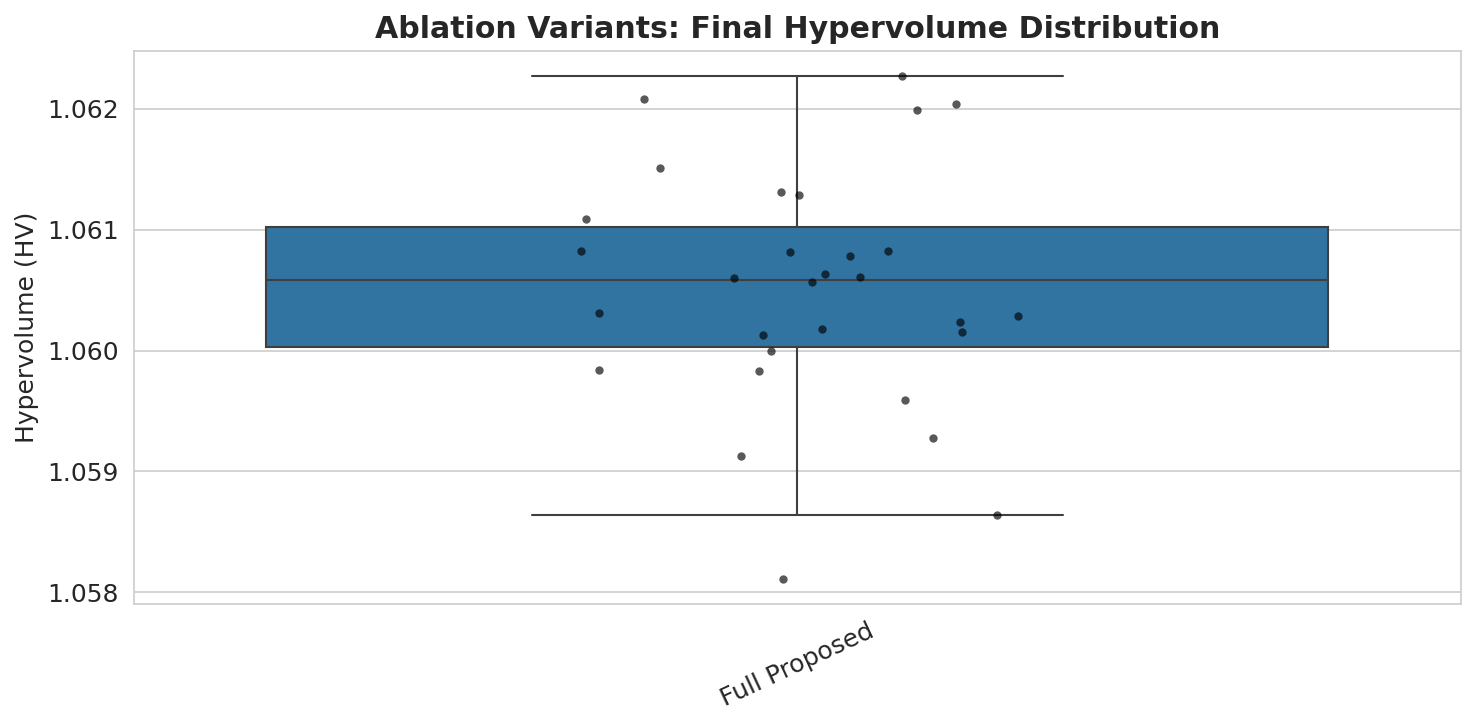

In [2]:
# ── Boxplot: Final HV Distribution Across Ablation Variants ───────────────
fig, ax = plt.subplots(figsize=(10, 5))

palette = sns.color_palette("tab10", n_colors=len(metrics_df["Variant"].cat.categories))
sns.boxplot(
    data=metrics_df,
    x="Variant",
    y="HV",
    ax=ax,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
)
sns.stripplot(
    data=metrics_df,
    x="Variant",
    y="HV",
    color="black",
    size=4,
    alpha=0.65,
    jitter=0.18,
    ax=ax,
)

ax.set_title("Ablation Variants: Final Hypervolume Distribution", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Hypervolume (HV)")
ax.tick_params(axis="x", rotation=25)
ax.legend([], [], frameon=False)

fig.tight_layout()
out_path = RESULTS_DIR / "ablation_hv_boxplot.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablations/ablation_median_hv_igd.pdf


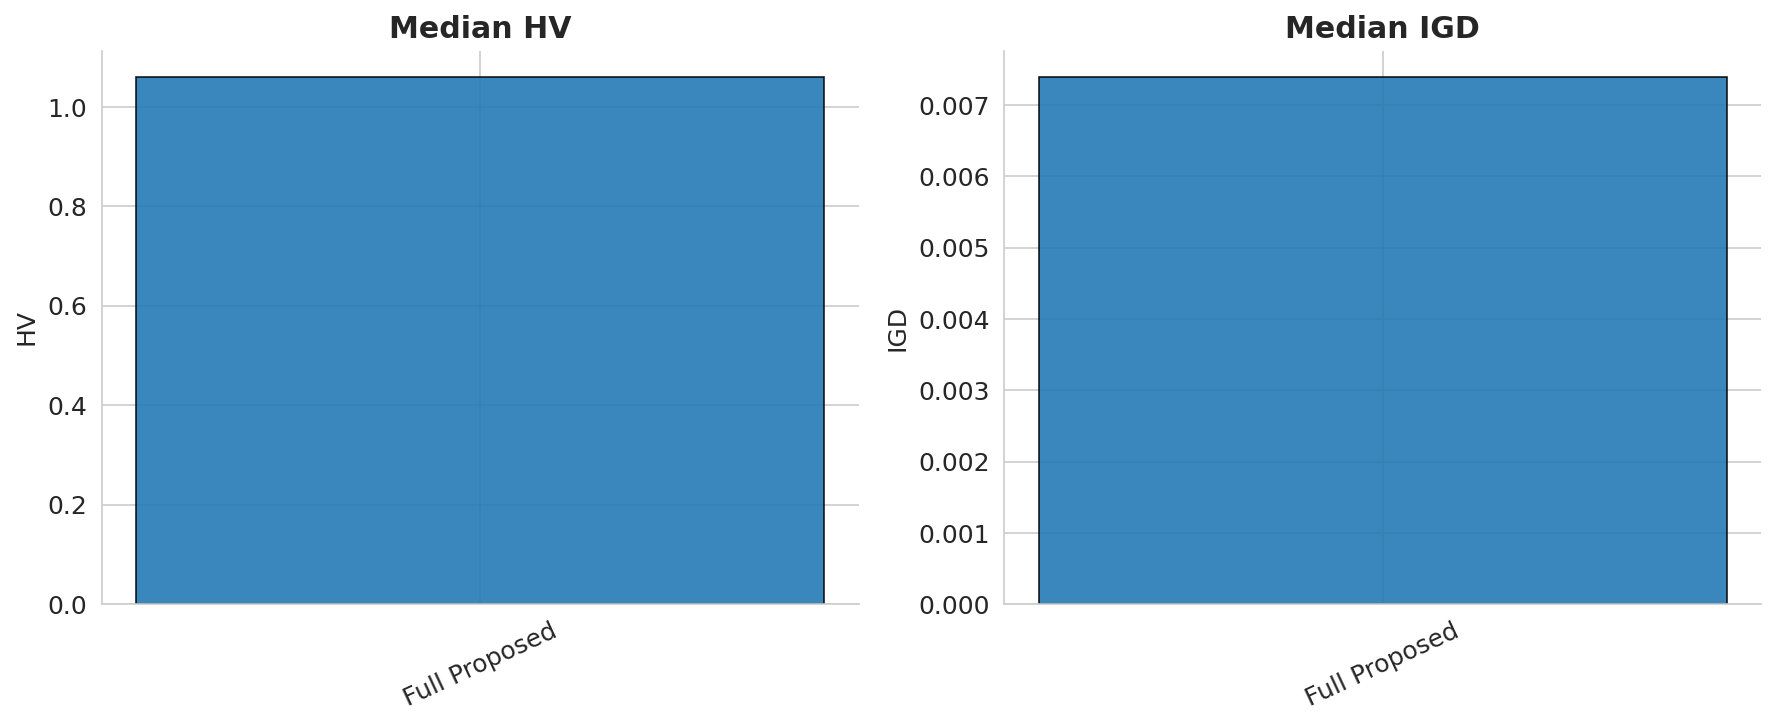

In [3]:
# ── Bar chart: Median HV and IGD per Ablation Variant ────────────────────
median_df = metrics_df.groupby("Variant")[ ["HV", "IGD"] ].median().reset_index()
metrics_melted = median_df.melt(id_vars=["Variant"], value_vars=["HV", "IGD"], var_name="Metric", value_name="Median")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
for metric, ax in zip(["HV", "IGD"], axes):
    subset = metrics_melted[metrics_melted["Metric"] == metric]
    ax.bar(
        subset["Variant"],
        subset["Median"],
        color=palette,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.88,
    )
    ax.set_title(f"Median {metric}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
out_path = RESULTS_DIR / "ablation_median_hv_igd.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablations/ablation_pareto_overlay.pdf


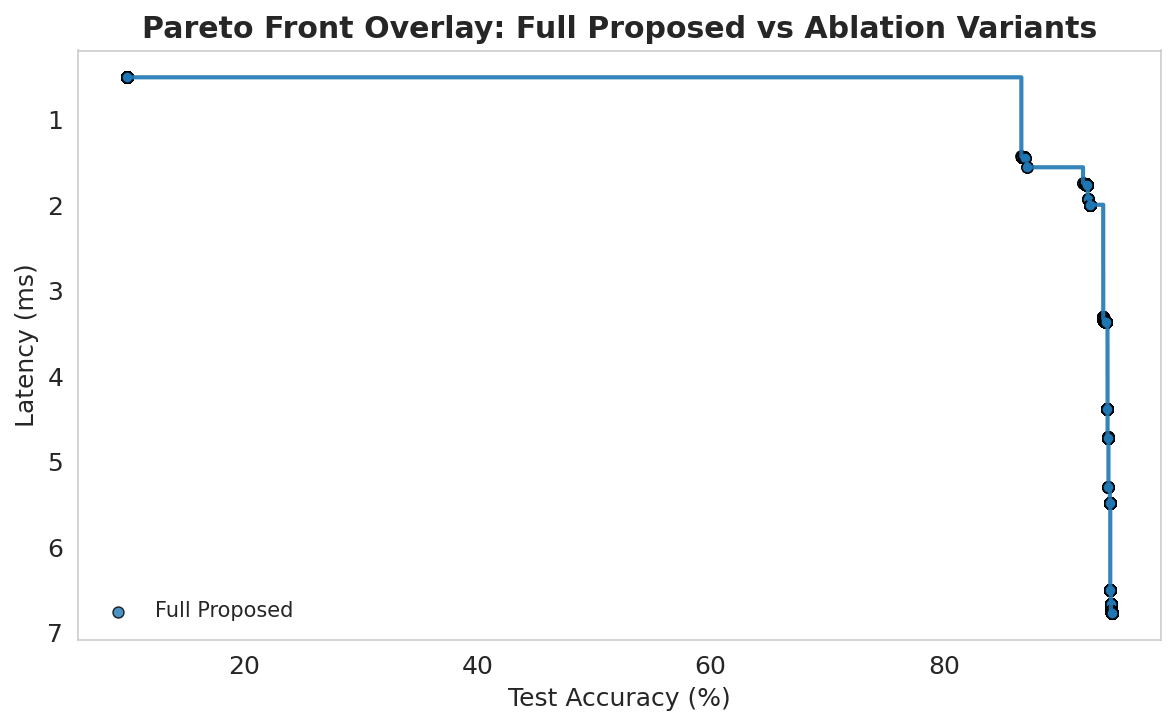

In [5]:
# ── Pareto Overlay: Full Proposed vs No GA vs No PSO ──────────────────────
selected_variants = [
    "full_proposed",
    "ablation_t3_no_ga",
    "ablation_t2_no_pso",
]
colors = ["#1f77b4", "#d62728", "#9467bd"]

fig, ax = plt.subplots(figsize=(8, 5))
for variant, color in zip(selected_variants, colors):
    if variant not in variant_paths:
        continue
    all_points = []
    for path in variant_paths[variant]:
        payload = json.loads(path.read_text())
        all_points.append(archive_to_points(payload["archive"]))
    all_points = np.vstack(all_points)
    front = get_pareto_front(all_points)
    acc = -front[:, 0]
    lat = front[:, 1]
    order = np.argsort(acc)
    ax.step(acc[order], lat[order], where="post", color=color, linewidth=2.0, alpha=0.9)
    ax.scatter(acc[order], lat[order], s=28, color=color, edgecolors="black", linewidth=0.7, alpha=0.8, label=LABEL_MAP.get(variant, variant))

ax.set_title("Pareto Front Overlay: Full Proposed vs Ablation Variants", fontweight="bold")
ax.set_xlabel("Test Accuracy (%)")
ax.set_ylabel("Latency (ms)")
ax.invert_yaxis()
ax.legend(frameon=False, fontsize=10)
ax.grid(False)

fig.tight_layout()
out_path = RESULTS_DIR / "ablation_pareto_overlay.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()